fisher-kpp on star graph
   dx = 0.05
   dt = 0.001
   CFL parameter r = 0.4000
   r < 0.5, should be stable
   Grid has 201 points on each edge
   Created arrays with shape (201,)
TASK 1: step-type initial condition

Initial condition set
   u1: min=1.0, max=1.0
   u2: min=1.0, max=1.0
   u3: min=0.0, max=0.0


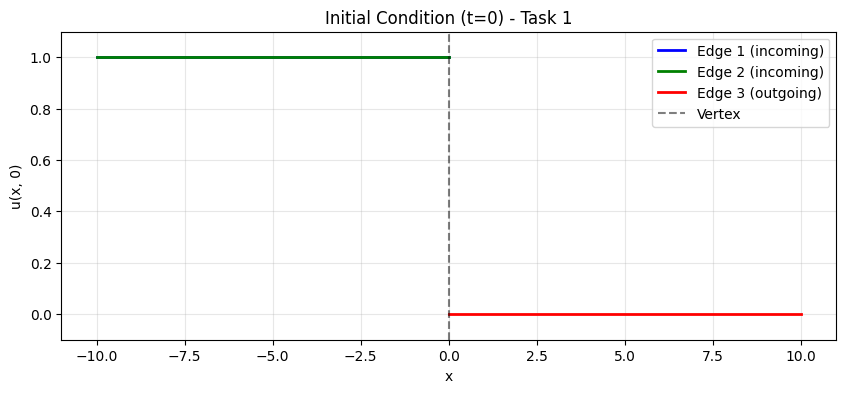


Running 20000 time steps...
   Step 2000/20000, t = 2.00
   Step 4000/20000, t = 4.00
   Step 6000/20000, t = 6.00
   Step 8000/20000, t = 8.00
   Step 10000/20000, t = 10.00
   Step 12000/20000, t = 12.00
   Step 14000/20000, t = 14.00
   Step 16000/20000, t = 16.00
   Step 18000/20000, t = 18.00
   Step 20000/20000, t = 20.00


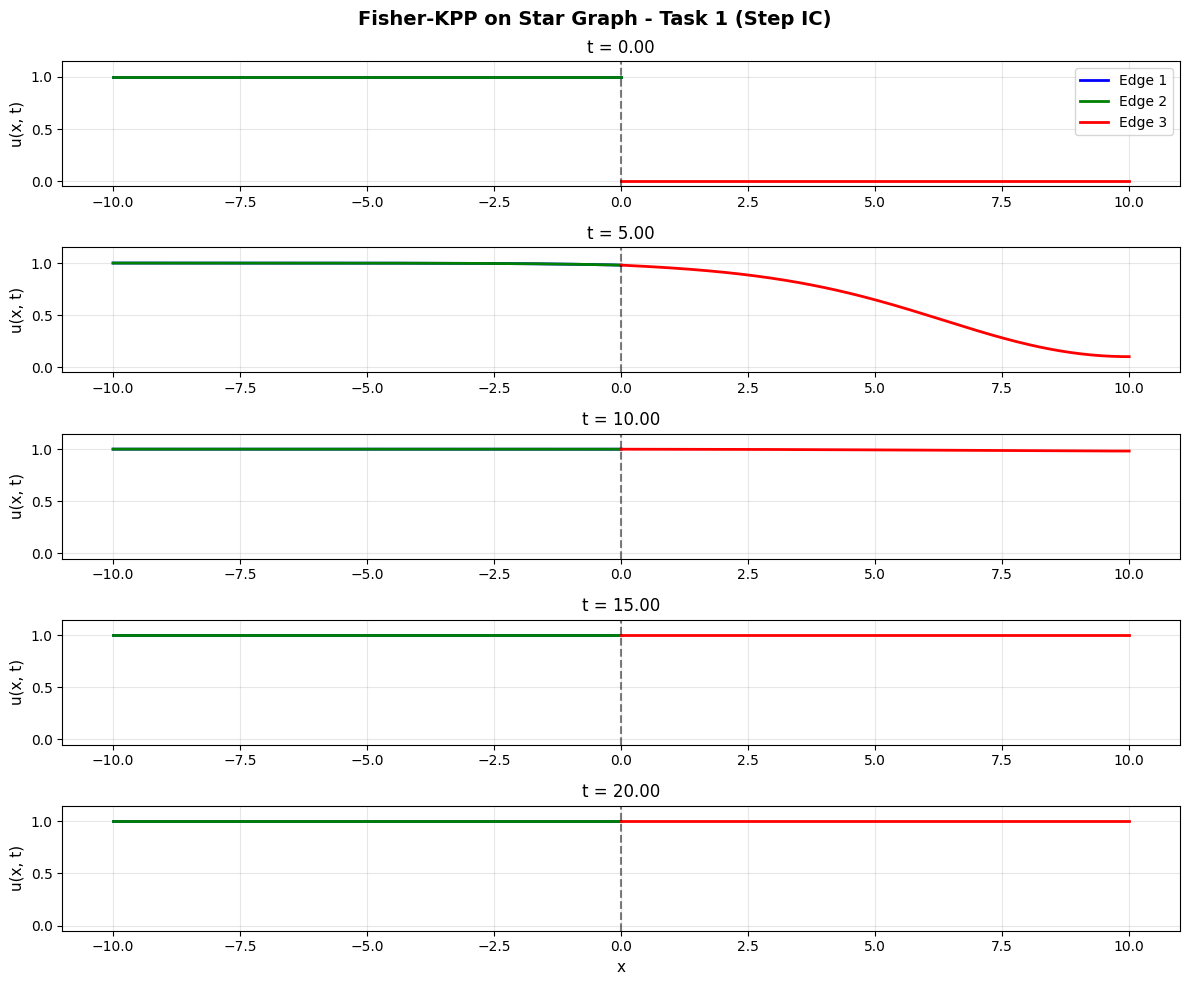


Task 1 Observations:
   - Wave propagates from edges 1,2 into edge 3
   - Forms a traveling wave front
   - Eventually saturates at u = 1
   - No jumps at the vertex, looks smooth
TASK 2: exponential initial condition

Running with λ = 0.5...
   Done - saved 101 snapshots

Running with λ = 1.0...
   Done - saved 101 snapshots

Running with λ = 2.0...
   Done - saved 101 snapshots


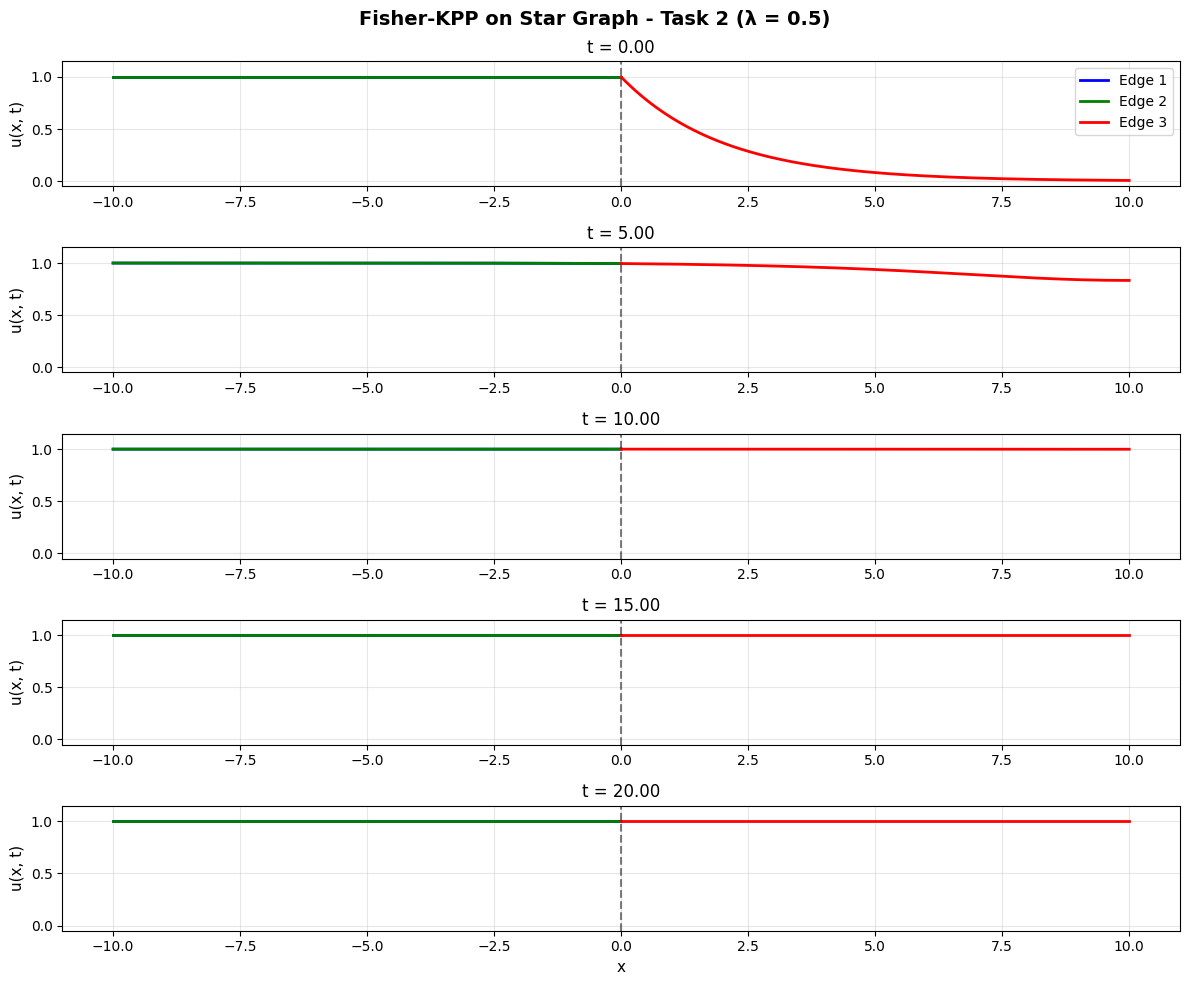

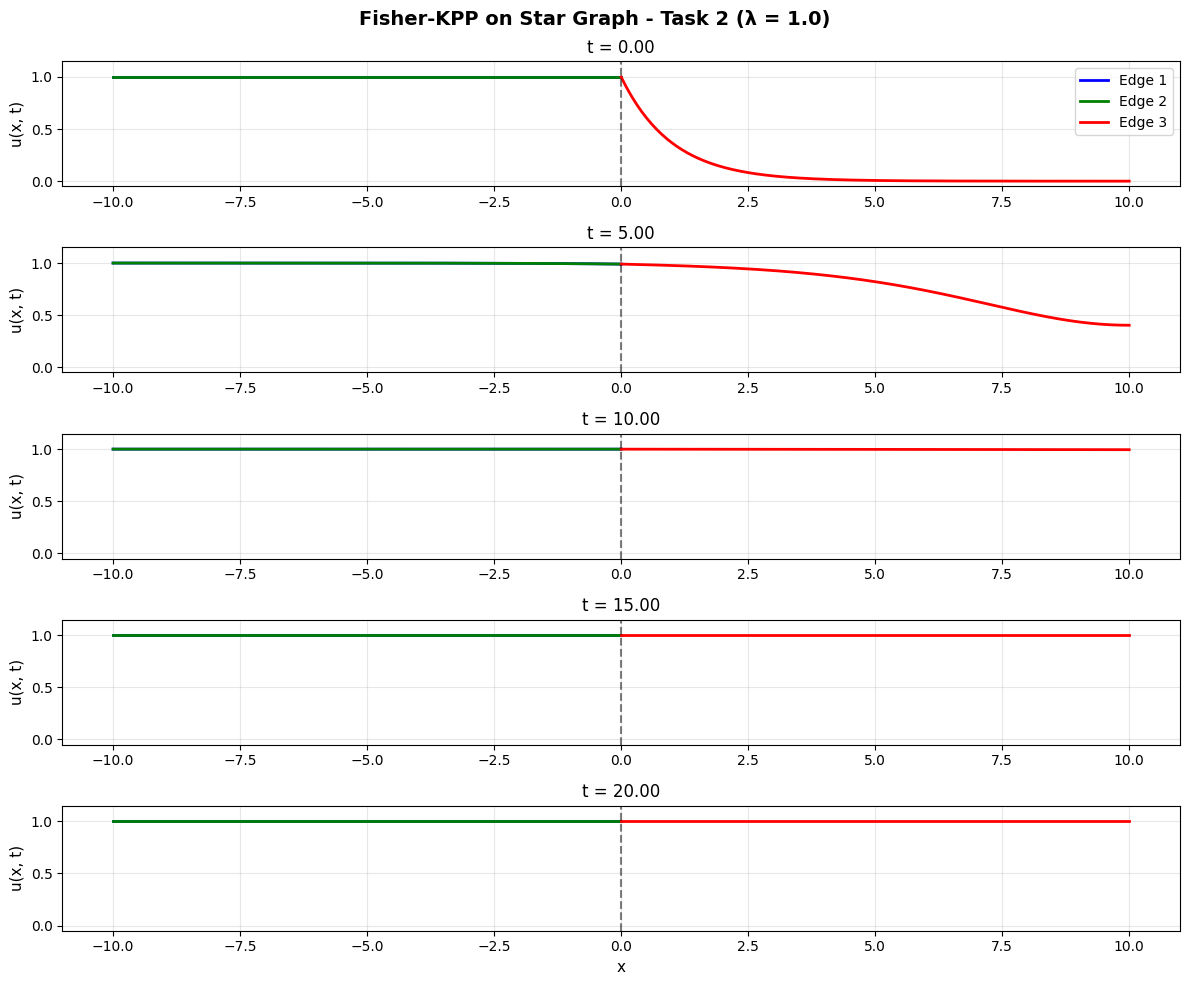

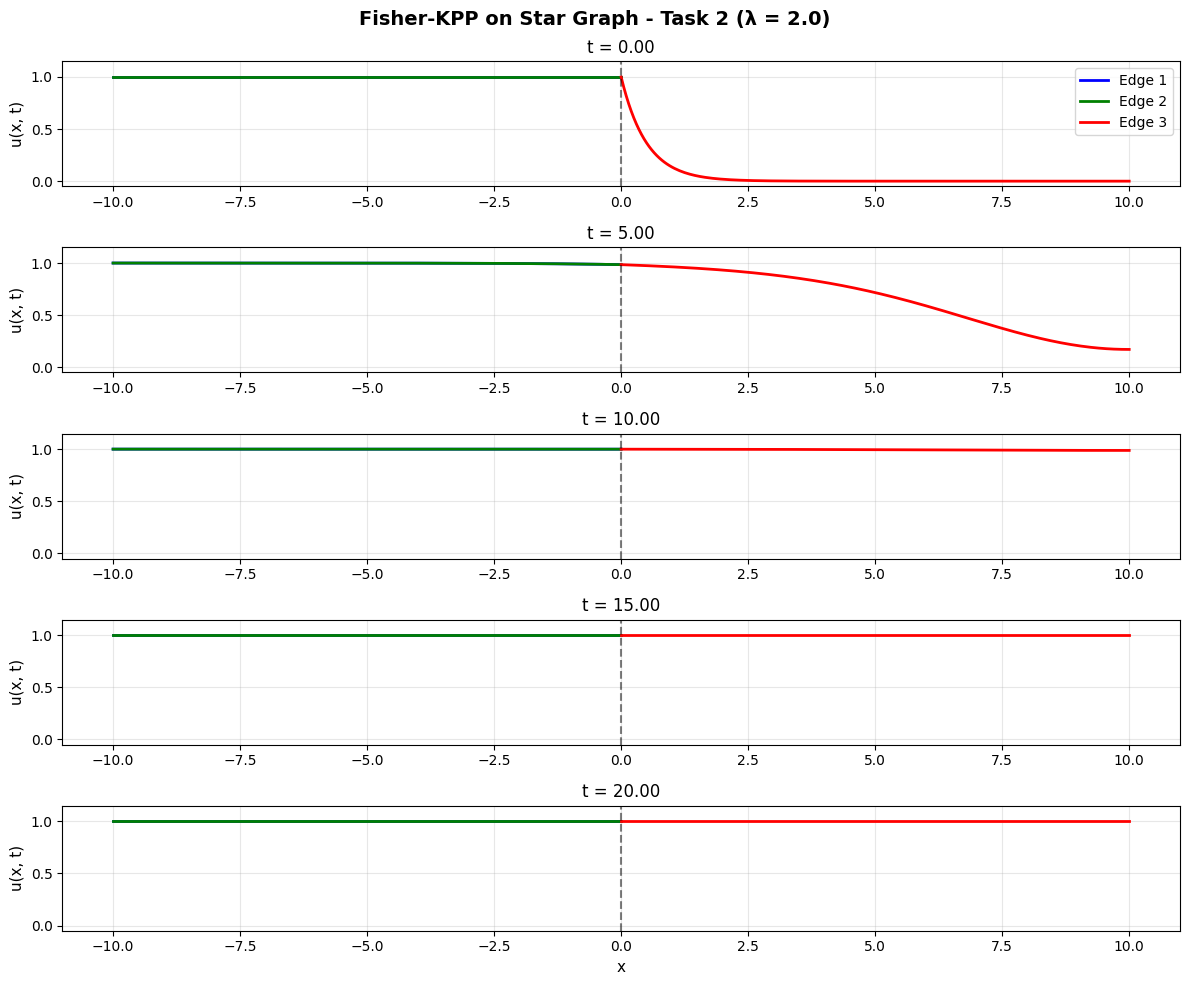

comparision of different λ values


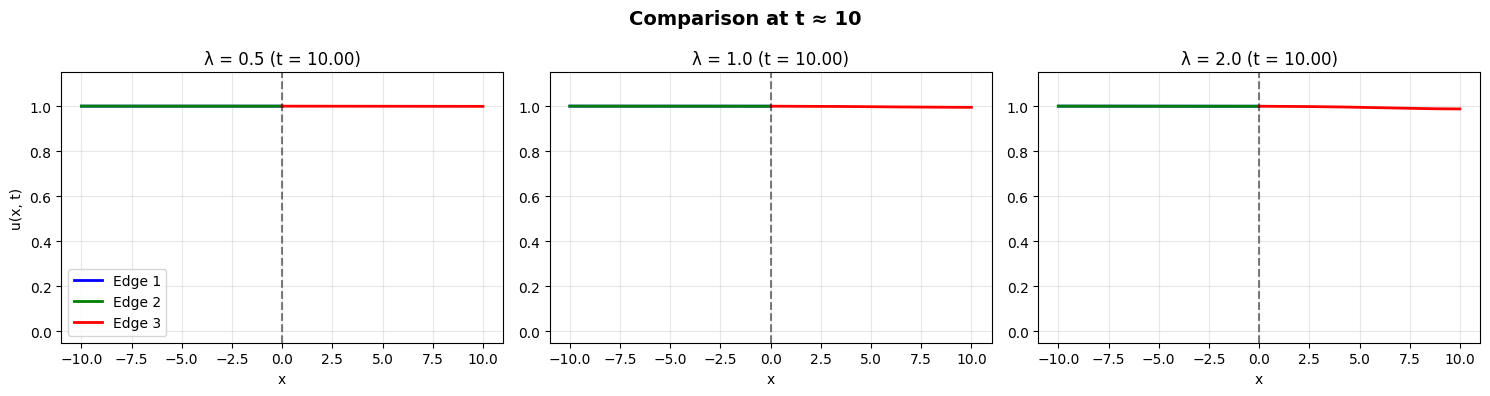


summary and observations

Task 1 (Step IC):
   - Wave moves from the vertex into edge 3
   - Sharp front smooths out quickly
   - Everything goes to u=1 in the end

Task 2 (Exponential IC):
   - λ = 0.5: smoother initial profile, fills in faster
   - λ = 1.0: good middle case, clear wave
   - λ = 2.0: steep initial gradient, acts like step case

General observations:
   - Vertex conditions work well, no weird jumps at x=0
   - Different starting conditions give different waves but same final state
   - CFL condition is important - need r < 0.5 for stability
   - Flux balance makes sense physically


In [3]:
# Fisher-KPP on Star Graph - Gabe Delgado & Darya Reutenko - February 2026
# Solving the Fisher-KPP equation on a star graph
# 2 incoming edges and 1 outgoing edge

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# make plots look better
plt.rcParams['figure.dpi'] = 100

print("fisher-kpp on star graph")

# 1. grid setup

# simulation parameters
L = 10.0        # edge length
N = 200         # number of grid points - more points = better accuracy
T = 20.0        # how long to run the simulation
dt = 0.001      # time step size - needs to be small for stability

# calculate dx
dx = L / N

# check stability - this is important!
# FTCS needs r = dt/dx^2 to be less than 0.5
r = dt / (dx**2)
print(f"   dx = {dx}")
print(f"   dt = {dt}")
print(f"   CFL parameter r = {r:.4f}")
if r > 0.5:
    print("   WARNING: r > 0.5, might get unstable results")
else:
    print("   r < 0.5, should be stable")

# create grids
# incoming edges go from -L to 0
x_incoming = np.linspace(-L, 0, N+1)

# outgoing edge goes from 0 to L
x_outgoing = np.linspace(0, L, N+1)

print(f"   Grid has {N+1} points on each edge")

# 2. initializing solution arrays

# need 3 arrays for the 3 edges
# u1 and u2 for incoming, u3 for outgoing
u1 = np.zeros(N+1)
u2 = np.zeros(N+1)
u3 = np.zeros(N+1)

print(f"   Created arrays with shape {u1.shape}")

# 3. defining functions

def apply_neumann_bc(u1, u2, u3, N):
    """
    Neumann boundary conditions at the ends
    This means zero derivative (no flux) at boundaries
    """
    # left boundaries - use ghost point method
    u1[0] = u1[1]
    u2[0] = u2[1]

    # right boundary
    u3[N] = u3[N-1]


def apply_vertex_conditions(u1, u2, u3, N):
    """
    Vertex conditions at x = 0

    Need two things:
    1. Continuity - all three edges have same value at vertex
    2. Flux balance - what flows in equals what flows out

    From the math we get: U_v = (u1[N-1] + u2[N-1] + u3[1]) / 3
    """
    # calculate vertex value
    U_v = (u1[N-1] + u2[N-1] + u3[1]) / 3.0

    # set this value at the vertex for all edges
    u1[N] = U_v    # vertex at index N for incoming edges
    u2[N] = U_v
    u3[0] = U_v    # vertex at index 0 for outgoing edge


def ftcs_step(u, r, dt, N):
    """
    One time step using FTCS
    Only updates interior points
    """
    u_new = np.zeros_like(u)

    # loop over interior points
    for j in range(1, N):
        # diffusion part
        diffusion = r * (u[j+1] - 2*u[j] + u[j-1])

        # reaction part - this is the u(1-u) term
        reaction = dt * u[j] * (1.0 - u[j])

        # add them together
        u_new[j] = u[j] + diffusion + reaction

    return u_new


def run_simulation(lam, L=10.0, N=200, T=20.0, dt=0.001, save_every=200):
    """
    Run full simulation with exponential IC
    lam is the decay parameter
    """
    # setup
    dx = L / N
    r = dt / (dx**2)
    n_steps = int(T / dt)
    x_incoming = np.linspace(-L, 0, N+1)
    x_outgoing = np.linspace(0, L, N+1)

    # initial condition - exponential decay on edge 3
    u1 = np.ones(N+1)
    u2 = np.ones(N+1)
    u3 = np.exp(-lam * x_outgoing)

    snapshots = [(u1.copy(), u2.copy(), u3.copy())]
    times = [0.0]

    # time loop
    for n in range(n_steps):
        apply_neumann_bc(u1, u2, u3, N)
        apply_vertex_conditions(u1, u2, u3, N)

        u1_new = ftcs_step(u1, r, dt, N)
        u2_new = ftcs_step(u2, r, dt, N)
        u3_new = ftcs_step(u3, r, dt, N)

        # update interior points only
        u1[1:N] = u1_new[1:N]
        u2[1:N] = u2_new[1:N]
        u3[1:N] = u3_new[1:N]

        # save snapshots
        if (n+1) % save_every == 0:
            snapshots.append((u1.copy(), u2.copy(), u3.copy()))
            times.append((n+1) * dt)

    return snapshots, times, x_incoming, x_outgoing

# 4. TASK 1: step-type initial condition

print("TASK 1: step-type initial condition")

# set initial condition for Task 1
u1[:] = 1.0  # incoming edge 1 starts at 1
u2[:] = 1.0  # incoming edge 2 starts at 1
u3[:] = 0.0  # outgoing edge starts at 0

print("\nInitial condition set")
print(f"   u1: min={u1.min()}, max={u1.max()}")
print(f"   u2: min={u2.min()}, max={u2.max()}")
print(f"   u3: min={u3.min()}, max={u3.max()}")

# plot initial condition
plt.figure(figsize=(10, 4))
plt.plot(x_incoming, u1, 'b-', linewidth=2, label='Edge 1 (incoming)')
plt.plot(x_incoming, u2, 'g-', linewidth=2, label='Edge 2 (incoming)')
plt.plot(x_outgoing, u3, 'r-', linewidth=2, label='Edge 3 (outgoing)')
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5, label='Vertex')
plt.xlabel('x')
plt.ylabel('u(x, 0)')
plt.title('Initial Condition (t=0) - Task 1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([-0.1, 1.1])
plt.show()

# figure out how many steps we need
n_steps = int(T / dt)
print(f"\nRunning {n_steps} time steps...")

# arrays to save snapshots for plotting later
save_every = 200
snapshots = []
times = []

# save initial state
snapshots.append((u1.copy(), u2.copy(), u3.copy()))
times.append(0.0)

# main time loop
for n in range(n_steps):
    # apply boundary conditions
    apply_neumann_bc(u1, u2, u3, N)

    # apply vertex conditions
    apply_vertex_conditions(u1, u2, u3, N)

    # do FTCS update
    u1_new = ftcs_step(u1, r, dt, N)
    u2_new = ftcs_step(u2, r, dt, N)
    u3_new = ftcs_step(u3, r, dt, N)

    # update arrays
    u1[1:N] = u1_new[1:N]
    u2[1:N] = u2_new[1:N]
    u3[1:N] = u3_new[1:N]

    # save if needed
    if (n+1) % save_every == 0:
        snapshots.append((u1.copy(), u2.copy(), u3.copy()))
        times.append((n+1) * dt)

    # print progress
    if (n+1) % 2000 == 0:
        print(f"   Step {n+1}/{n_steps}, t = {(n+1)*dt:.2f}")

# pick 5 times to plot
n_snaps = len(times)
plot_indices = [0, n_snaps//4, n_snaps//2, 3*n_snaps//4, n_snaps-1]

# make figure
fig, axes = plt.subplots(len(plot_indices), 1, figsize=(12, 10))
fig.suptitle('Fisher-KPP on Star Graph - Task 1 (Step IC)', fontsize=14, fontweight='bold')

for i, idx in enumerate(plot_indices):
    u1_snap, u2_snap, u3_snap = snapshots[idx]
    t = times[idx]

    ax = axes[i]

    # plot all three edges
    ax.plot(x_incoming, u1_snap, 'b-', linewidth=2, label='Edge 1')
    ax.plot(x_incoming, u2_snap, 'g-', linewidth=2, label='Edge 2')
    ax.plot(x_outgoing, u3_snap, 'r-', linewidth=2, label='Edge 3')
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5)

    ax.set_ylabel('u(x, t)', fontsize=11)
    ax.set_title(f't = {t:.2f}', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.15])

    if i == 0:
        ax.legend(loc='best')
    if i == len(plot_indices) - 1:
        ax.set_xlabel('x', fontsize=11)

plt.tight_layout()
plt.show()

print("\nTask 1 Observations:")
print("   - Wave propagates from edges 1,2 into edge 3")
print("   - Forms a traveling wave front")
print("   - Eventually saturates at u = 1")
print("   - No jumps at the vertex, looks smooth")

# 5. TASK 2: exponential initial condition
print("TASK 2: exponential initial condition")

# try different lambda values
lambda_values = [0.5, 1.0, 2.0]

results = {}
for lam in lambda_values:
    print(f"\nRunning with λ = {lam}...")
    snaps, t, x_in, x_out = run_simulation(lam)
    results[lam] = {'snapshots': snaps, 'times': t, 'x_in': x_in, 'x_out': x_out}
    print(f"   Done - saved {len(t)} snapshots")

# plot results for each lambda

for lam in lambda_values:
    data = results[lam]
    snapshots = data['snapshots']
    times = data['times']
    x_in = data['x_in']
    x_out = data['x_out']

    # pick 5 snapshots
    n_snaps = len(times)
    plot_indices = [0, n_snaps//4, n_snaps//2, 3*n_snaps//4, n_snaps-1]

    fig, axes = plt.subplots(len(plot_indices), 1, figsize=(12, 10))
    fig.suptitle(f'Fisher-KPP on Star Graph - Task 2 (λ = {lam})',
                 fontsize=14, fontweight='bold')

    for i, idx in enumerate(plot_indices):
        u1_snap, u2_snap, u3_snap = snapshots[idx]
        t = times[idx]

        ax = axes[i]
        ax.plot(x_in, u1_snap, 'b-', linewidth=2, label='Edge 1')
        ax.plot(x_in, u2_snap, 'g-', linewidth=2, label='Edge 2')
        ax.plot(x_out, u3_snap, 'r-', linewidth=2, label='Edge 3')
        ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5)

        ax.set_ylabel('u(x, t)', fontsize=11)
        ax.set_title(f't = {t:.2f}', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([-0.05, 1.15])

        if i == 0:
            ax.legend(loc='best')
        if i == len(plot_indices) - 1:
            ax.set_xlabel('x', fontsize=11)

    plt.tight_layout()
    plt.show()

# 6. comparision of different λ values
print("comparision of different λ values")

# compare at t = 10
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Comparison at t ≈ 10', fontsize=14, fontweight='bold')

for i, lam in enumerate(lambda_values):
    data = results[lam]
    snapshots = data['snapshots']
    times = data['times']
    x_in = data['x_in']
    x_out = data['x_out']

    # find closest snapshot to t=10
    idx = min(range(len(times)), key=lambda i: abs(times[i] - 10.0))
    u1, u2, u3 = snapshots[idx]
    t_actual = times[idx]

    ax = axes[i]
    ax.plot(x_in, u1, 'b-', linewidth=2, label='Edge 1')
    ax.plot(x_in, u2, 'g-', linewidth=2, label='Edge 2')
    ax.plot(x_out, u3, 'r-', linewidth=2, label='Edge 3')
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5)
    ax.set_title(f'λ = {lam} (t = {t_actual:.2f})')
    ax.set_xlabel('x')
    ax.set_ylim([-0.05, 1.15])
    ax.grid(True, alpha=0.3)

    if i == 0:
        ax.set_ylabel('u(x, t)')
        ax.legend()

plt.tight_layout()
plt.show()

# 7. summary
print("\n" + "="*70)
print("summary and observations")
print("="*70)

print("\nTask 1 (Step IC):")
print("   - Wave moves from the vertex into edge 3")
print("   - Sharp front smooths out quickly")
print("   - Everything goes to u=1 in the end")

print("\nTask 2 (Exponential IC):")
print("   - λ = 0.5: smoother initial profile, fills in faster")
print("   - λ = 1.0: good middle case, clear wave")
print("   - λ = 2.0: steep initial gradient, acts like step case")

print("\nGeneral observations:")
print("   - Vertex conditions work well, no weird jumps at x=0")
print("   - Different starting conditions give different waves but same final state")
print("   - CFL condition is important - need r < 0.5 for stability")
print("   - Flux balance makes sense physically")